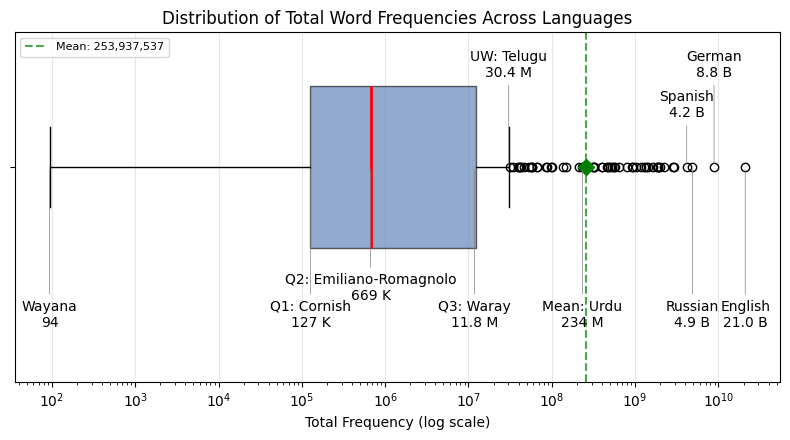

Q1: 126,464  |  Median: 674,531  |  Q3: 12,441,371  |  Mean: 253,937,537
Min: 94  |  Max: 20,952,813,381  |  Count: 288
Upper whisker limit: 30,913,732

── Annotated languages vs actual data ──
  way  Wayana                     total_freq =              94
  cor  Cornish                    total_freq =         127,170
  eml  Emiliano-Romagnolo         total_freq =         669,110
  war  Waray (Philippines)        total_freq =      11,848,305
  tel  Telugu                     total_freq =      30,422,159
  urd  Urdu                       total_freq =     233,773,148
  spa  Spanish                    total_freq =   4,160,457,389
  rus  Russian                    total_freq =   4,873,917,160
  deu  German                     total_freq =   8,846,049,483
  eng  English                    total_freq =  20,952,813,381


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../../results/0_data_processing/statistics.csv")
sc = pd.read_csv("../../src/0_data_processing/corpora/leipzig/lepzig_shortcuts.csv")
code_to_name = dict(zip(sc["code"], sc["language"]))
df["name"] = df["file"].map(code_to_name).fillna(df["file"])

s = df["total_frequency"].dropna()
q1, q2, q3 = s.quantile([0.25, 0.50, 0.75])
iqr = q3 - q1
mean = s.mean()
upper_whisker_limit = q3 + 1.5 * iqr

BOTTOM = -0.55
TOP = 0.38

fig, ax = plt.subplots(figsize=(8, 4.5))
bp = ax.boxplot(s, vert=False, widths=0.6, patch_artist=True,
                boxprops=dict(facecolor="#4C72B0", alpha=0.6),
                medianprops=dict(color="red", linewidth=2),
                showmeans=True,
                meanprops=dict(marker="D", markerfacecolor="green", markeredgecolor="green", markersize=8))

ax.axvline(mean, color="green", linestyle="--", alpha=0.7, label=f"Mean: {mean:,.0f}")

# Annotations: (value, name, y_offset direction)
annotations = [
    (94, "Wayana\n94", BOTTOM),
    (127_170, "Q1: Cornish\n127 K", BOTTOM),
    (669_110, "Q2: Emiliano-Romagnolo\n669 K", BOTTOM + 0.1),
    (11_848_305, "Q3: Waray\n11.8 M", BOTTOM),
    (30_422_159, "UW: Telugu\n30.4 M", TOP),
    (233_773_148, "Mean: Urdu\n234 M", BOTTOM),
    (4_160_457_389, "Spanish\n4.2 B", TOP - 0.15),
    (4_873_917_160, "Russian\n4.9 B", BOTTOM),
    (8_846_049_483, "German\n8.8 B", TOP),
    (20_952_813_381, "English\n21.0 B", BOTTOM),
]

for val, label, y_off in annotations:
    ax.annotate(label, xy=(val, 1), xytext=(val, 1 + y_off),
                fontsize=10, ha="center", va="center",
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

ax.set_xscale("log")
ax.set_xlabel("Total Frequency (log scale)")
ax.set_title("Distribution of Total Word Frequencies Across Languages")
ax.set_yticklabels([])
ax.set_ylim(0.2, 1.5)
ax.legend(loc="upper left", fontsize=8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Q1: {q1:,.0f}  |  Median: {q2:,.0f}  |  Q3: {q3:,.0f}  |  Mean: {mean:,.0f}")
print(f"Min: {s.min():,.0f}  |  Max: {s.max():,.0f}  |  Count: {len(s)}")
print(f"Upper whisker limit: {upper_whisker_limit:,.0f}")

# Verify annotated values against actual data
print("\n── Annotated languages vs actual data ──")
check = ["way", "cor", "eml", "war", "tel", "urd", "spa", "rus", "deu", "eng"]
for code in check:
    row = df[df["file"] == code]
    if not row.empty:
        print(f"  {code}  {row.iloc[0]['name']:<25s}  total_freq = {row.iloc[0]['total_frequency']:>15,}")
    else:
        print(f"  {code}  NOT FOUND")